<a href="https://colab.research.google.com/github/Alakhg1408/PES2UG24CS051_VDUI_2/blob/branch-3/unit2_ppt5_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [3]:
# TODO 1: choropleth of total_gdp
fig_total = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="total_gdp",
    hover_name="country",
    color_continuous_scale="Viridis",
    title="World Total GDP (2007) — Count / Aggregate",
)
fig_total.show()

# TODO 2: choropleth of gdpPercap
fig_rate = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="gdpPercap",
    hover_name="country",
    color_continuous_scale="Viridis",
    title="World GDP per Capita (2007) — Rate / Normalized",
)
fig_rate.show()

# TODO 3: top 5 countries by each -- print both lists
top_total = gap_latest.sort_values("total_gdp", ascending=False)[
    ["country", "total_gdp"]
].head(5)
top_rate = gap_latest.sort_values("gdpPercap", ascending=False)[
    ["country", "gdpPercap"]
].head(5)

print("Top 5 by total GDP:\n", top_total.to_string(index=False))
print("\nTop 5 by GDP per capita:\n", top_rate.to_string(index=False))

Top 5 by total GDP:
       country    total_gdp
United States 1.293446e+13
        China 6.539501e+12
        Japan 4.035135e+12
        India 2.722925e+12
      Germany 2.650871e+12

Top 5 by GDP per capita:
       country   gdpPercap
       Norway 49357.19017
       Kuwait 47306.98978
    Singapore 47143.17964
United States 42951.65309
      Ireland 40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

_Your answer:_ China, Japan, India, and Germany appear in the top-5 for total GDP due to their massive population sizes, but none of them make the top-5 for GDP per capita (where smaller, high-wealth nations like Norway, Kuwait, Singapore, and Ireland dominate).   I would show the director the GDP per capita (rate) map. Raw aggregates produce a "population map in disguise" where land area and population inflate visual salience; normalizing by population yields an honest cross-national comparison of actual living standards.

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

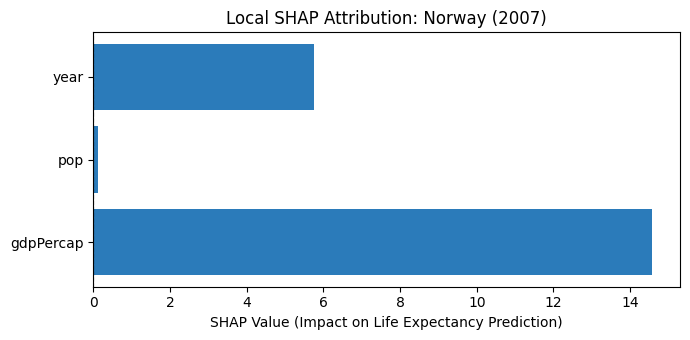

In [4]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values
feature_names = ["gdpPercap", "pop", "year"]

# TODO 1: fit the model
rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_model, y_model)

# TODO 2: SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# TODO 3: find Norway's row, plot its SHAP contributions
row_idx = gapminder[
    (gapminder.country == "Norway") & (gapminder.year == 2007)
].index[0]
vals = shap_values[row_idx]

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["#2b7bba" if v > 0 else "#d95f02" for v in vals]
ax.barh(feature_names, vals, color=colors)
ax.axvline(0, color="black", lw=0.8, linestyle="--")
ax.set_xlabel("SHAP Value (Impact on Life Expectancy Prediction)")
ax.set_title("Local SHAP Attribution: Norway (2007)")
plt.tight_layout()
plt.show()

**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_ gdpPercap contributed most positively to Norway's predicted life expectancy, followed positively by year, while pop had a negligible/slightly negative contribution due to Norway's small population size. This local breakdown cannot be inferred from global feature importance alone; global importance only states that GDP per capita is important on average across the whole world, but local SHAP explains the exact sign and magnitude of why a specific country received its individual predicted value

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

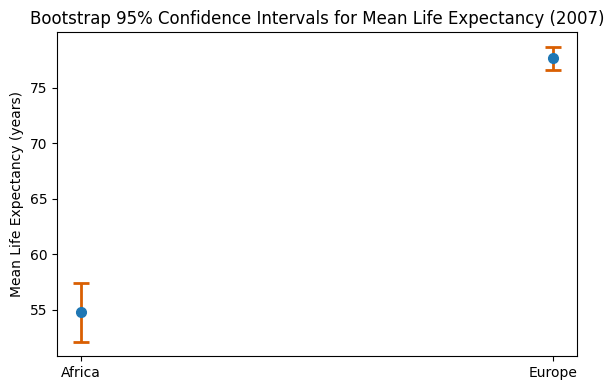

In [5]:
def bootstrap_ci(values, n_boot=2000, seed=0):
  rng = np.random.default_rng(seed)
  # Resample with replacement n_boot times
  boot_means = [
      rng.choice(values, size=len(values), replace=True).mean()
      for _ in range(n_boot)
  ]
  return (
      np.mean(values),
      np.percentile(boot_means, 2.5),
      np.percentile(boot_means, 97.5),
  )


# Compute CIs for Africa and Europe
continent_a, continent_b = "Africa", "Europe"
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)

# Plot both as error bars
fig, ax = plt.subplots(figsize=(6, 4))
labels = [continent_a, continent_b]
means = [result_a[0], result_b[0]]
yerr_lower = [result_a[0] - result_a[1], result_b[0] - result_b[1]]
yerr_upper = [result_a[2] - result_a[0], result_b[2] - result_b[0]]

ax.errorbar(
    labels,
    means,
    yerr=[yerr_lower, yerr_upper],
    fmt="o",
    capsize=6,
    capthick=2,
    color="#1f77b4",
    ecolor="#d95f02",
    elinewidth=2,
    markersize=7,
)
ax.set_ylabel("Mean Life Expectancy (years)")
ax.set_title("Bootstrap 95% Confidence Intervals for Mean Life Expectancy (2007)")
plt.tight_layout()
plt.show()

**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_ Africa has a significantly wider confidence interval (~5.3 years vs. ~2.1 years for Europe). This wider interval is driven by much higher internal variance (standard deviation $\approx 9.54$ years in Africa vs. $2.93$ years in Europe) across diverse countries, despite Africa having a larger country sample size ($n=52$ vs $n=30$). High within-group heterogeneity widens standard error and expands the uncertainty band.

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

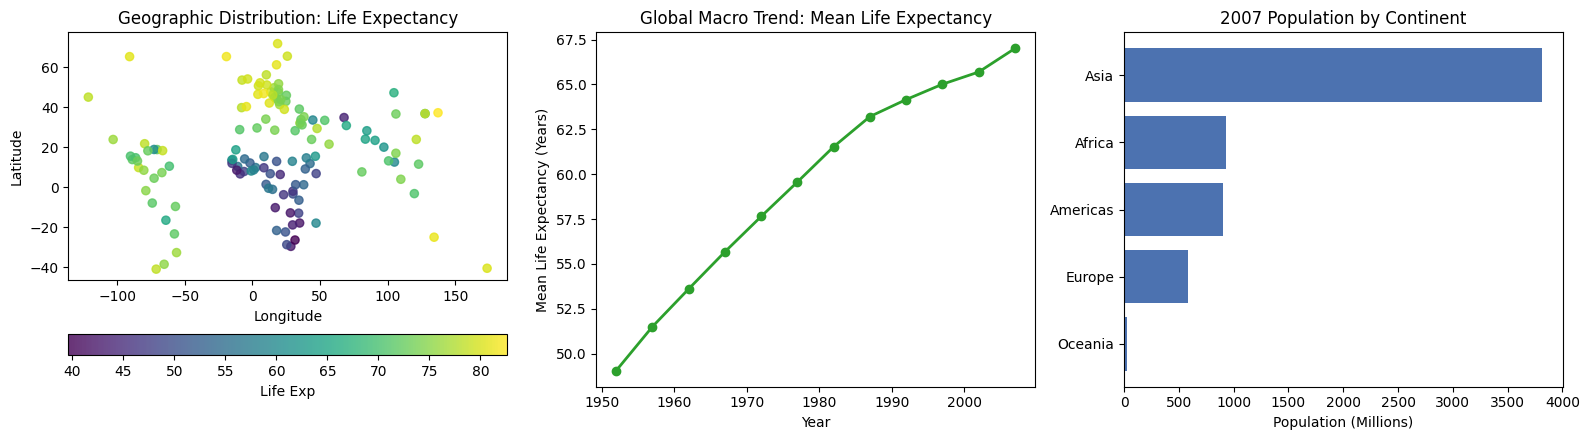

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Map-style scatter of country centroids (axes[0])
sc = axes[0].scatter(
    gap_latest["centroid_lon"],
    gap_latest["centroid_lat"],
    c=gap_latest["lifeExp"],
    cmap="viridis",
    s=35,
    alpha=0.8,
)
plt.colorbar(sc, ax=axes[0], orientation="horizontal", pad=0.15, label="Life Exp")
axes[0].set_title("Geographic Distribution: Life Expectancy")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# 2. World trend line (axes[1])
world_trend = gapminder.groupby("year")["lifeExp"].mean().reset_index()
axes[1].plot(
    world_trend["year"],
    world_trend["lifeExp"],
    marker="o",
    color="#2ca02c",
    lw=2,
)
axes[1].set_title("Global Macro Trend: Mean Life Expectancy")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean Life Expectancy (Years)")

# 3. Population by continent in 2007 (axes[2])
pop_continent = (
    gap_latest.groupby("continent")["pop"].sum().sort_values(ascending=True)
)
axes[2].barh(pop_continent.index, pop_continent.values / 1e6, color="#4C72B0")
axes[2].set_title("2007 Population by Continent")
axes[2].set_xlabel("Population (Millions)")

plt.tight_layout()
plt.show()

**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_ For a 5-second morning glance, I would keep the world trend line (Panel 2). Per the lecture's focus on operational monitoring, it is the only panel that immediately signals macro trends and temporal trajectory, alerting the director whether global development is progressing steadily or stalling, before drilling into regional or geographic exceptions.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_ For all future public briefings, we will standardize exclusively on rate-normalized choropleths (such as GDP per capita) rather than raw aggregate counts, eliminating the distortion where geographical area falsely amplifies sparsely populated nations. When addressing journalist inquiries regarding individual countries, we must lead with local SHAP feature attributions rather than global model importances, because global metrics obscure localized non-linearities and country-specific drivers. Lastly, regional mean estimates (such as continental life expectancy) must never be published as bare point values without uncertainty intervals, as doing so masks severe underlying health disparities and varying degrees of statistical variance across member nations.